In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch08_v3"

In [3]:
epoches, steps = [], []
train_losses, val_losses = [], []
learning_rates, created_at = [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    tag = f.name.replace("checkpoint_", "").replace(".json", "")
    epoches.append(int(tag.split("-", 1)[0]))
    steps.append(int(tag.split("-", 1)[-1]))
    train_losses.append(data['train_loss'])
    val_losses.append(data['val_loss'])
    learning_rates.append(data['learning_rate'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "epoch": epoches,
    "step": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "learning_rate": learning_rates,
    "created_at": created_at,
})


df = df.sort_values(by='step', ascending=True)

print(df.nsmallest(1, 'train_loss'))

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

#pd.concat((df.head(10), df.tail(10)))
df

    epoch     step  train_loss  val_loss  learning_rate  \
33      6  1040000    0.929685  2.679667       0.000038   

                created_at  
33  2025-09-12T17:10:12%:z  


,epoch,step,train_loss,val_loss,learning_rate,created_at
31,1,8000,4.540999,4.591301,0.000025,2025-09-10T00:22:20%:z
21,1,16000,3.703147,3.936172,0.000051,2025-09-10T00:42:57%:z
105,1,24000,2.812141,3.178871,0.000076,2025-09-10T01:03:33%:z
59,1,32000,2.404786,2.897669,0.000102,2025-09-10T01:24:09%:z
9,1,40000,2.162816,2.759679,0.000127,2025-09-10T01:44:47%:z
...,...,...,...,...,...,...
128,6,1104000,0.934263,2.658504,0.000053,2025-09-12T20:49:49%:z
102,6,1112000,0.938351,2.638894,0.000055,2025-09-12T21:16:01%:z
73,6,1120000,0.935206,2.662245,0.000057,2025-09-12T21:42:14%:z
63,6,1128000,0.932597,2.683653,0.000060,2025-09-12T22:08:28%:z


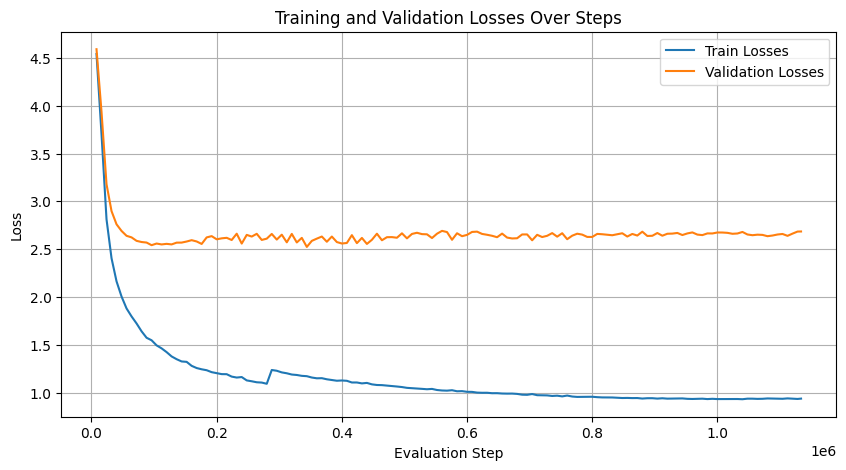

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Losses")
plt.plot(df['step'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

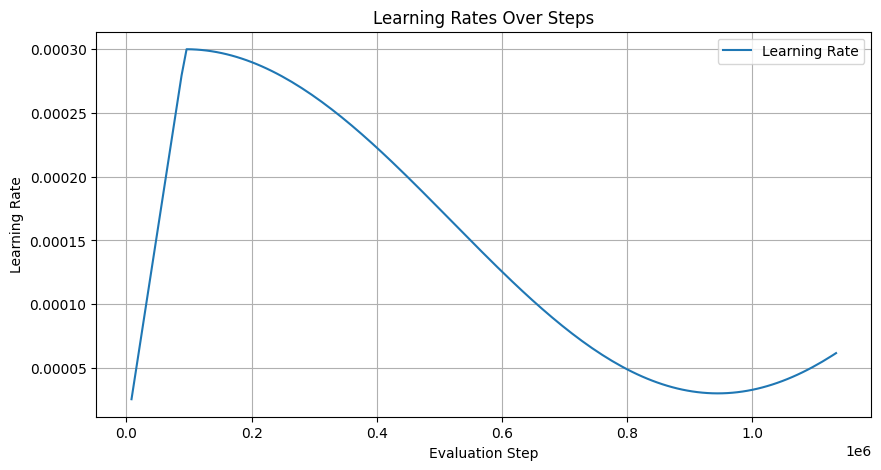

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")